<a href="https://colab.research.google.com/github/LevTsaturyan/ML_2025_autumn/blob/main/ML7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Решающие деревья, случайные леса и градиентный бустинг

### О задании

Задание состоит из трёх разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.  
3. В третьем разделе вы попробуете градиентный бустинг на практической задаче.

Прежде чем приступать к работе, рекомендую прочитать теорию.  
Построение решающего дерева осуществляется согласно базовому жадному алгоритму, описанному в [лекции 8](https://github.com/esokolov/ml-course-hse/blob/master/2016-fall/lecture-notes/lecture07-trees.pdf) в разделе «Построение дерева». Выбор лучшего разбиения производиться по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

Построение случайного леса описано в лекции [8](https://github.com/esokolov/ml-course-hse/blob/master/2016-fall/lecture-notes/lecture08-ensembles.pdf), про градиентный бустинг [9](https://github.com/esokolov/ml-course-hse/blob/master/2016-fall/lecture-notes/lecture09-ensembles.pdf), про стекинг и блендинг в лекции  [10](https://github.com/esokolov/ml-course-hse/blob/master/2016-fall/lecture-notes/lecture10-ensembles.pdf)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [ ]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0., )
]

InvalidParameterError: The 'n_redundant' parameter of make_classification must be an int in the range [0, inf). Got 0.0 instead.

In [ ]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

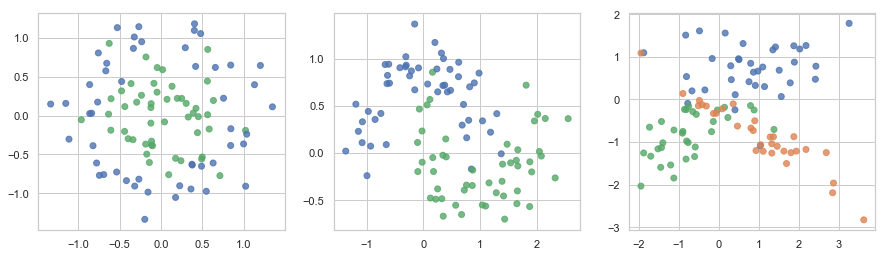

In [ ]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__1.1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [ ]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

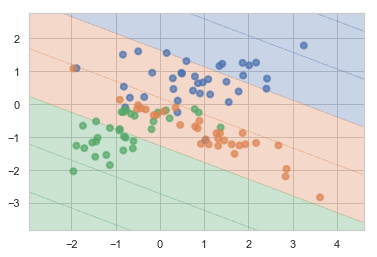

In [ ]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder


In [ ]:
def plot_surface(clf, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

In [ ]:
def load_dataset(path):
    df = pd.read_csv(path, header=None)

    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    for col in X.columns:
        X[col] = LabelEncoder().fit_transform(X[col])

    y = LabelEncoder().fit_transform(y)

    return X.iloc[:, :2].values, y


Mushroom: train=0.434, test=0.421


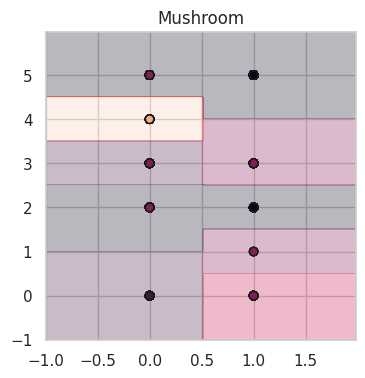

Car: train=0.705, test=0.690


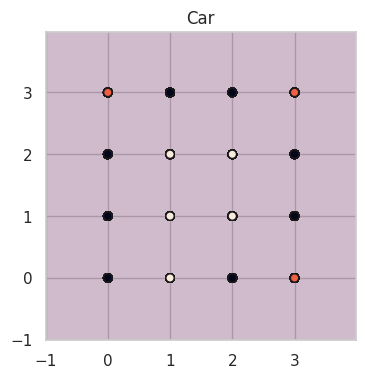

Nursery: train=0.533, test=0.527


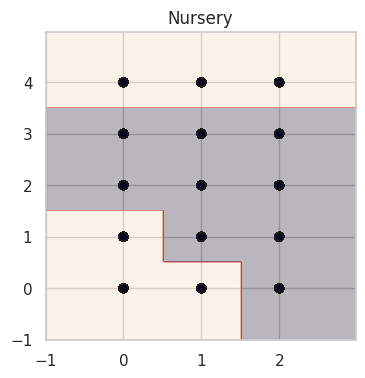

TicTacToe: train=0.661, test=0.632


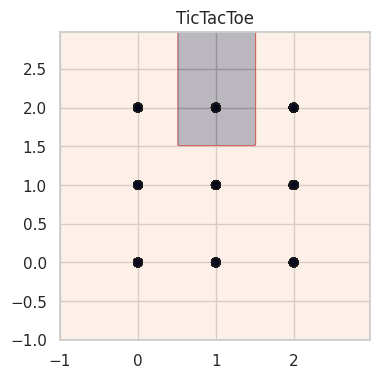

In [ ]:
datasets = {
    'Mushroom': 'agaricus-lepiota.data',
    'Car': 'car.data',
    'Nursery': 'nursery.data',
    'TicTacToe': 'tic-tac-toe.data'
}

for name, path in datasets.items():
    X, y = load_dataset(path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    print(f'{name}: train={train_acc:.3f}, test={test_acc:.3f}')

    plt.figure(figsize=(4, 4))
    plot_surface(clf, X, y)
    plt.title(name)
    plt.show()

__Ответ:__

__1.2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

In [ ]:
def plot_surface(clf, X, y):
    X = X[:, :2]

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')


__Ответ:__

In [ ]:
def load_dataset(path, target_first=False):
    df = pd.read_csv(path, header=None)

    if target_first:
        X = df.iloc[:, 1:]
        y = df.iloc[:, 0]
    else:
        X = df.iloc[:, :-1]
        y = df.iloc[:, -1]

    for col in X.columns:
        X[col] = LabelEncoder().fit_transform(X[col])

    y = LabelEncoder().fit_transform(y)
    return X.values, y



Mushroom
  1: train=1.000, test=1.000
  2: train=1.000, test=1.000
  3: train=0.979, test=0.979
  4: train=0.998, test=0.998


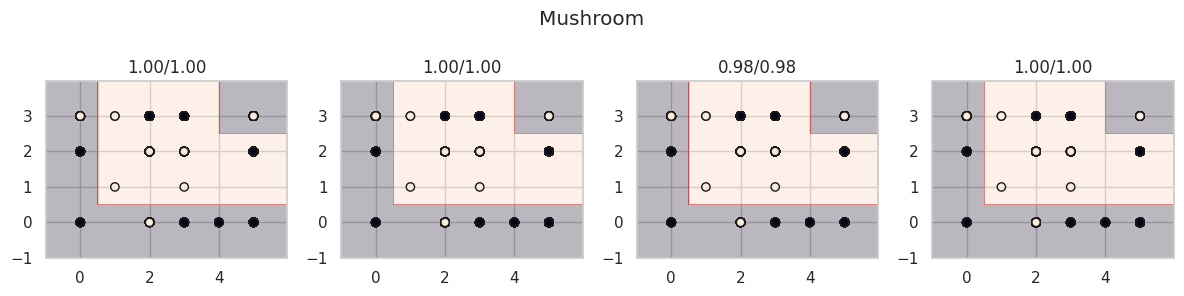


Car
  1: train=1.000, test=0.971
  2: train=0.993, test=0.958
  3: train=0.857, test=0.863
  4: train=0.948, test=0.933


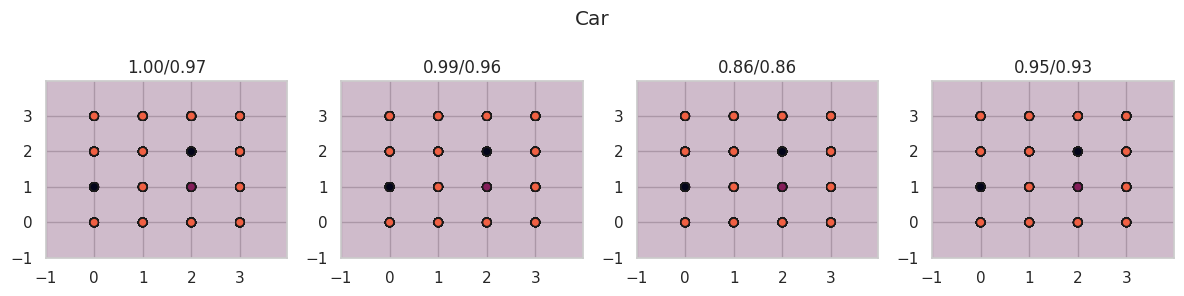


Nursery
  1: train=1.000, test=0.995
  2: train=0.975, test=0.967
  3: train=0.875, test=0.880
  4: train=0.977, test=0.972


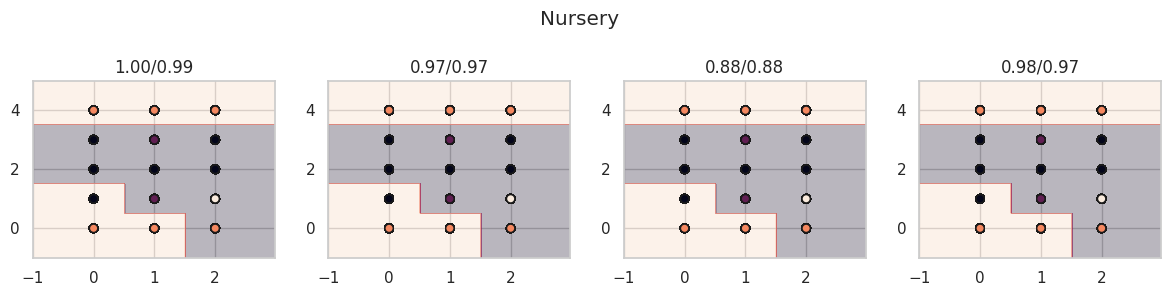


TicTacToe
  1: train=1.000, test=0.906
  2: train=1.000, test=0.906
  3: train=0.831, test=0.809
  4: train=0.860, test=0.785


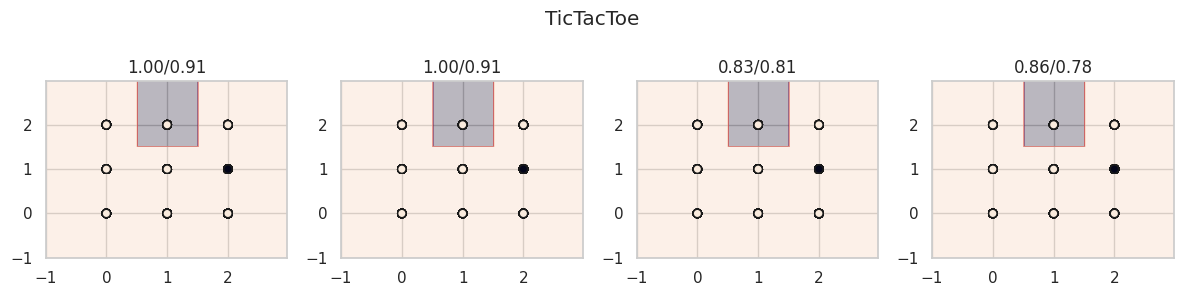

In [ ]:
datasets = {
    'Mushroom': ('agaricus-lepiota.data', True),
    'Car': ('car.data', False),
    'Nursery': ('nursery.data', False),
    'TicTacToe': ('tic-tac-toe.data', False)
}

params = [
    {'max_depth': None, 'min_samples_leaf': 1},
    {'max_depth': 10, 'min_samples_leaf': 1},
    {'max_depth': 5, 'min_samples_leaf': 1},
    {'max_depth': None, 'min_samples_leaf': 10},
]

for name, (path, first) in datasets.items():
    X, y = load_dataset(path, first)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    print(f'\n{name}')

    plt.figure(figsize=(12, 3))

    for i, p in enumerate(params):
        clf = DecisionTreeClassifier(
            max_depth=p['max_depth'],
            min_samples_leaf=p['min_samples_leaf'],
            random_state=42
        )

        clf.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, clf.predict(X_train))
        test_acc = accuracy_score(y_test, clf.predict(X_test))

        print(f'  {i+1}: train={train_acc:.3f}, test={test_acc:.3f}')

        clf_vis = DecisionTreeClassifier(
            max_depth=p['max_depth'],
            min_samples_leaf=p['min_samples_leaf'],
            random_state=42
        )
        clf_vis.fit(X_train[:, :2], y_train)

        plt.subplot(1, len(params), i + 1)
        plot_surface(clf_vis, X_train[:, :2], y_train)
        plt.title(f'{train_acc:.2f}/{test_acc:.2f}')

    plt.suptitle(name)
    plt.tight_layout()
    plt.show()



# 2. Решающие деревья на 5 датасетах

__2.1. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (из [Data Folder](https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/)), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [ ]:

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

data = pd.read_csv('agaricus-lepiota.data', header=None)
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

#кодирование категориальных признаков
X = X.apply(LabelEncoder().fit_transform)
y_encoded = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y_encoded, test_size=0.5, random_state=42, stratify=y_encoded)

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Глубина дерева:", clf.tree_.max_depth)

Accuracy: 1.0
Глубина дерева: 7


__2.2. (2 балла)__

Загрузите следующие наборы данных (все датасеты уже скачаны для удобства в папку datasets), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names):
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце),
* [tic-tac-toe](https://archive.ics.uci.edu/dataset/101/tic+tac+toe+endgame) (классы записаны в последнем столбце)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).
* [user-knowledge-modeling](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling) (классы не бинарные: High, Middle, Low, very_low)

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTreeClassifier, считающий все признаки вещественными
* DecisionTreeClassifier, считающий все признаки категориальными
* DecisionTreeClassifier, считающий все признаки вещественными + one-hot-encoding всех признаков  

Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder.

ЗАДАНИЕ 2.2: СРАВНЕНИЕ РАЗНЫХ СПОСОБОВ КОДИРОВАНИЯ ПРИЗНАКОВ

1. Mushroom: 8124 объектов, 22 признаков

2. Tic-Tac-Toe: 958 объектов, 9 признаков

3. Cars: 1728 объектов, 6 признаков

4. Nursery: 12960 объектов, 8 признаков

5. User Knowledge (synthetic) dataset использован

ВСЕГО ЗАГРУЖЕНО ДАТАСЕТОВ: 5
  • Mushroom: Mushroom: 22 признаков, 2 классов
  • Tic-Tac-Toe: Tic-Tac-Toe: 9 признаков, 2 классов
  • Cars: Cars: 6 признаков, 2 класса
  • Nursery: Nursery: 8 признаков, 2 класса
  • User Knowledge (synthetic): User Knowledge (synthetic): 5 признаков, 4 класса

ОЦЕНКА ДЛЯ ДАТАСЕТА: Mushroom
  Результаты: {'Numeric': np.float64(1.0), 'Categorical': np.float64(1.0), 'One-Hot': np.float64(1.0)}

ОЦЕНКА ДЛЯ ДАТАСЕТА: Tic-Tac-Toe
  Результаты: {'Numeric': np.float64(0.8883552631578947), 'Categorical': np.float64(0.8883552631578947), 'One-Hot': np.float64(0.9426425438596491)}

ОЦЕНКА ДЛЯ ДАТАСЕТА: Cars
  Результаты: {'Numeric': np.float64(0.9918907111170856), 'Categorical': np.float64(0.9

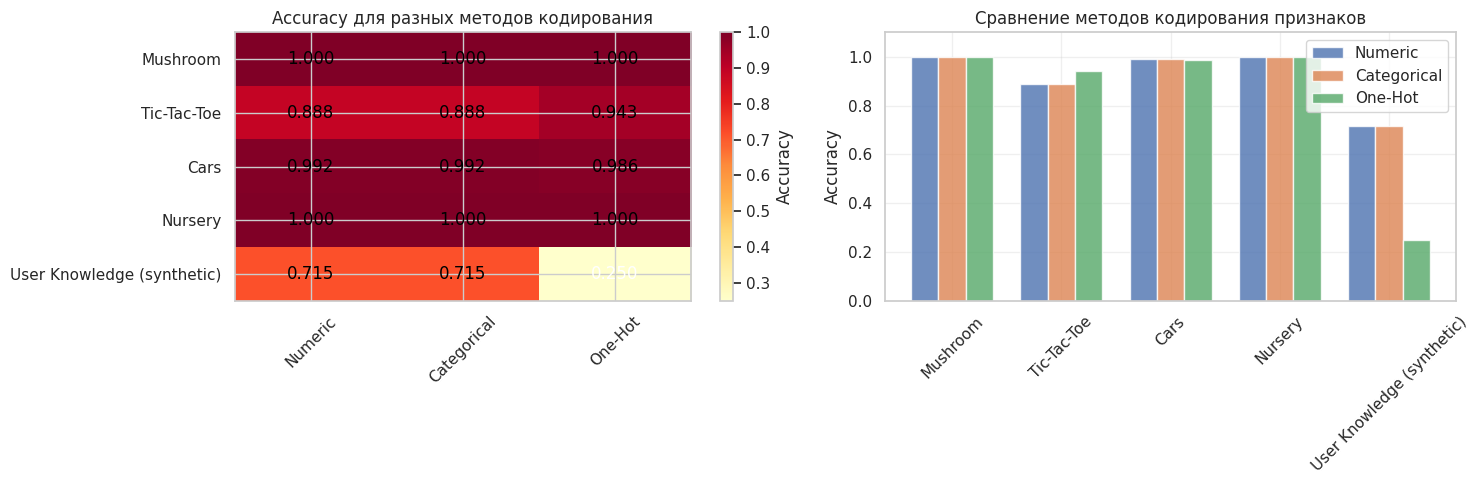


Результаты сохранены в файл: results_2_2.csv

ЗАДАНИЕ 2.2 ВЫПОЛНЕНО


In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold, train_test_split
from sklearn.metrics import accuracy_score, make_scorer
import warnings, os
warnings.filterwarnings('ignore')

print("="*80)
print("ЗАДАНИЕ 2.2: СРАВНЕНИЕ РАЗНЫХ СПОСОБОВ КОДИРОВАНИЯ ПРИЗНАКОВ")
print("="*80)

def load_and_prepare_datasets():
    datasets = {}

    try:
        mushroom_data = pd.read_csv('agaricus-lepiota.data', header=None)
        X_mush, y_mush = mushroom_data.iloc[:,1:], mushroom_data.iloc[:,0]
        y_mush_encoded = LabelEncoder().fit_transform(y_mush.astype(str))
        X_mush_label = X_mush.apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
        datasets['Mushroom'] = {'X': X_mush_label.values, 'y': y_mush_encoded, 'X_raw': X_mush.values, 'description': f"Mushroom: {X_mush.shape[1]} признаков, {len(np.unique(y_mush_encoded))} классов"}
        print(f"\n1. Mushroom: {X_mush.shape[0]} объектов, {X_mush.shape[1]} признаков")
    except: pass

    try:
        ttt_data = pd.read_csv('tic-tac-toe.data', header=None)
        X_ttt, y_ttt = ttt_data.iloc[:,:-1], ttt_data.iloc[:,-1]
        y_ttt_encoded = LabelEncoder().fit_transform(y_ttt.astype(str))
        X_ttt_label = X_ttt.apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
        datasets['Tic-Tac-Toe'] = {'X': X_ttt_label.values, 'y': y_ttt_encoded, 'X_raw': X_ttt.values, 'description': f"Tic-Tac-Toe: {X_ttt.shape[1]} признаков, {len(np.unique(y_ttt_encoded))} классов"}
        print(f"\n2. Tic-Tac-Toe: {X_ttt.shape[0]} объектов, {X_ttt.shape[1]} признаков")
    except: pass

    try:
        cars_data = pd.read_csv('car.data', header=None)
        X_cars, y_cars = cars_data.iloc[:,:-1], cars_data.iloc[:,-1]
        y_cars_binary = np.array([1 if v in ['good','vgood'] else 0 for v in y_cars])
        X_cars_label = X_cars.apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
        datasets['Cars'] = {'X': X_cars_label.values, 'y': y_cars_binary, 'X_raw': X_cars.values, 'description': f"Cars: {X_cars.shape[1]} признаков, 2 класса"}
        print(f"\n3. Cars: {X_cars.shape[0]} объектов, {X_cars.shape[1]} признаков")
    except: pass

    try:
        nursery_data = pd.read_csv('nursery.data', header=None)
        X_nurs, y_nurs = nursery_data.iloc[:,:-1], nursery_data.iloc[:,-1]
        y_nurs_binary = np.array([1 if v in ['very_recom','priority','spec_prior'] else 0 for v in y_nurs])
        X_nurs_label = X_nurs.apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
        datasets['Nursery'] = {'X': X_nurs_label.values, 'y': y_nurs_binary, 'X_raw': X_nurs.values, 'description': f"Nursery: {X_nurs.shape[1]} признаков, 2 класса"}
        print(f"\n4. Nursery: {X_nurs.shape[0]} объектов, {X_nurs.shape[1]} признаков")
    except: pass

    try:
        uk_files = [f for f in os.listdir('.') if 'user' in f.lower() or 'knowledge' in f.lower() or 'Data_User' in f]
        if uk_files:
            uk_file = uk_files[0]
            uk_data = pd.read_excel(uk_file) if uk_file.endswith(('xls','xlsx')) else pd.read_csv(uk_file)
            target_col = next((c for c in ['UNS','Class','CLASS','target','Target','label','Label'] if c in uk_data.columns), uk_data.columns[-1])
            y_uk_encoded = LabelEncoder().fit_transform(uk_data[target_col].astype(str))
            X_uk_label = uk_data.drop(target_col, axis=1).apply(lambda col: LabelEncoder().fit_transform(col.astype(str)) if col.dtype=='object' else col)
            datasets['User Knowledge'] = {'X': X_uk_label.values, 'y': y_uk_encoded, 'X_raw': uk_data.drop(target_col, axis=1).values, 'description': f"User Knowledge: {X_uk_label.shape[1]} признаков, {len(np.unique(y_uk_encoded))} классов"}
            print(f"\n5. User Knowledge: {X_uk_label.shape[0]} объектов, {X_uk_label.shape[1]} признаков")
        else:
            from sklearn.datasets import make_classification
            X_synth, y_synth = make_classification(n_samples=400, n_features=5, n_informative=3, n_redundant=1, n_classes=4, random_state=42)
            datasets['User Knowledge (synthetic)'] = {'X': X_synth, 'y': y_synth, 'X_raw': X_synth, 'description': "User Knowledge (synthetic): 5 признаков, 4 класса"}
            print("\n5. User Knowledge (synthetic) dataset использован")
    except:
        from sklearn.datasets import make_classification
        X_synth, y_synth = make_classification(n_samples=400, n_features=5, n_informative=3, n_redundant=1, n_classes=4, random_state=42)
        datasets['User Knowledge (synthetic)'] = {'X': X_synth, 'y': y_synth, 'X_raw': X_synth, 'description': "User Knowledge (synthetic): 5 признаков, 4 класса"}
    return datasets

datasets = load_and_prepare_datasets()
if not datasets:
    print("\nНе удалось загрузить ни одного датасета!"); exit()

print(f"\n{'='*80}\nВСЕГО ЗАГРУЖЕНО ДАТАСЕТОВ: {len(datasets)}")
for name,data in datasets.items():
    print(f"  • {name}: {data['description']}")

def get_optimal_cv(y):
    counts = np.unique(y, return_counts=True)[1]
    min_class_size = np.min(counts)
    return min(10, min_class_size) if min_class_size>=10 else min(5,min_class_size) if min_class_size>=5 else min(3,min_class_size) if min_class_size>=3 else 2 if min_class_size>=2 else None

def evaluate_models(name, X, y, X_raw):
    print(f"\n{'='*60}\nОЦЕНКА ДЛЯ ДАТАСЕТА: {name}")
    n_folds = get_optimal_cv(y)
    results = {}
    if n_folds is None or n_folds<2:
        X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)
        eval_split = lambda model, Xt, Xv, yt, yv: accuracy_score(yv, model.fit(Xt,yt).predict(Xv))
        results['Numeric'] = eval_split(DecisionTreeClassifier(random_state=42), X_train, X_test, y_train, y_test)
        results['Categorical'] = eval_split(DecisionTreeClassifier(random_state=42), X_train, X_test, y_train, y_test)
        encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
        X_train_enc, X_test_enc = encoder.fit_transform(X_train), encoder.transform(X_test)
        results['One-Hot'] = eval_split(DecisionTreeClassifier(random_state=42,max_depth=10), X_train_enc, X_test_enc, y_train, y_test)
    else:
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42) if len(np.unique(y))>1 else KFold(n_splits=n_folds, shuffle=True, random_state=42)
        results['Numeric'] = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=cv, scoring=make_scorer(accuracy_score), n_jobs=-1).mean()
        results['Categorical'] = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=cv, scoring=make_scorer(accuracy_score), n_jobs=-1).mean()
        X_onehot = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit_transform(X_raw)
        results['One-Hot'] = cross_val_score(DecisionTreeClassifier(random_state=42,max_depth=10), X_onehot, y, cv=cv, scoring=make_scorer(accuracy_score), n_jobs=-1).mean()
    print(f"  Результаты: {results}")
    return results

all_results = {name:evaluate_models(name,data['X'],data['y'],data['X_raw']) for name,data in datasets.items()}
results_df = pd.DataFrame(all_results).T[['Numeric','Categorical','One-Hot']]
print("\nAccuracy для разных методов кодирования признаков:")
print(results_df.round(4))

dataset_info = pd.DataFrame({'Объектов':[datasets[n]['X'].shape[0] for n in results_df.index],'Признаков (исходных)':[datasets[n]['X'].shape[1] for n in results_df.index],'Классов':[len(np.unique(datasets[n]['y'])) for n in results_df.index]}, index=results_df.index)
print("\nИНФОРМАЦИЯ О ДАТАСЕТАХ")
print(dataset_info)

best_methods = {name:row.idxmax() for name,row in results_df.iterrows()}
print("\nЛучший метод по каждому датасету:")
for name in results_df.index:
    best, worst = results_df.loc[name].idxmax(), results_df.loc[name].idxmin()
    diff = results_df.loc[name,best]-results_df.loc[name,worst]
    print(f"  {name}: лучший={best}, худший={worst}, разница={diff:.4f}")

method_counts = {m: sum(1 for v in best_methods.values() if v == m) for m in results_df.columns}
print("\nСколько раз каждый метод был лучшим:", method_counts)
print("\nСредняя accuracy по всем датасетам:")
print(results_df.mean())

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1,2,figsize=(15,5))
    ax1=axes[0]; ax2=axes[1]
    heat_data = np.where(np.isnan(results_df.values), 0, results_df.values)
    im = ax1.imshow(heat_data,cmap='YlOrRd',aspect='auto')
    ax1.set_xticks(range(len(results_df.columns))); ax1.set_xticklabels(results_df.columns,rotation=45)
    ax1.set_yticks(range(len(results_df.index))); ax1.set_yticklabels(results_df.index)
    for i in range(len(results_df.index)):
        for j in range(len(results_df.columns)):
            val=results_df.iloc[i,j]; ax1.text(j,i,'N/A' if np.isnan(val) else f"{val:.3f}",ha='center',va='center',color='black' if val>0.7 else 'white')
    ax1.set_title("Accuracy для разных методов кодирования")
    plt.colorbar(im,ax=ax1,label='Accuracy')
    x=np.arange(len(results_df.index)); width=0.25
    for i, method in enumerate(results_df.columns):
        vals=np.where(np.isnan(results_df[method].values),0,results_df[method].values)
        ax2.bar(x+(i-1)*width,vals,width,label=method,alpha=0.8)
    ax2.set_xticks(x); ax2.set_xticklabels(results_df.index,rotation=45)
    ax2.set_ylim(0,1.1); ax2.set_title("Сравнение методов кодирования признаков"); ax2.set_ylabel("Accuracy"); ax2.legend(); ax2.grid(True,alpha=0.3)
    plt.tight_layout(); plt.show()
except: pass

results_df.to_csv('results_2_2.csv')
print("\nРезультаты сохранены в файл: results_2_2.csv")
print("\nЗАДАНИЕ 2.2 ВЫПОЛНЕНО")

__2.3. (бонус, 1 балл)__

Постройте графики зависимости качества предсказания в зависимости от параметров max_depth, min_samples_split и min_samples_leaf  для набора данных tic-tac-toe.

✓ Данные загружены: 958 объектов, 9 признаков


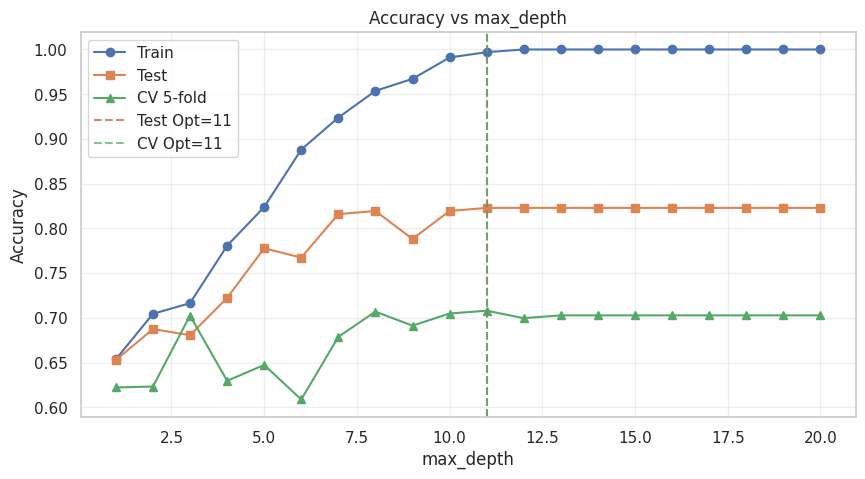

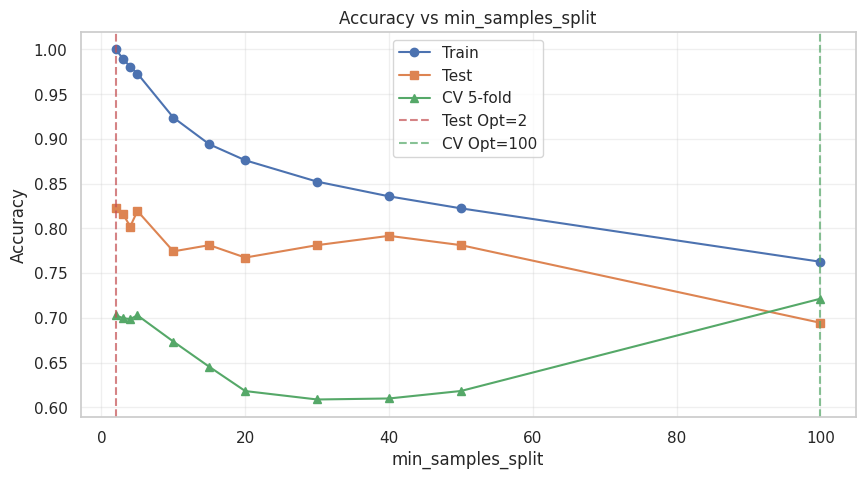

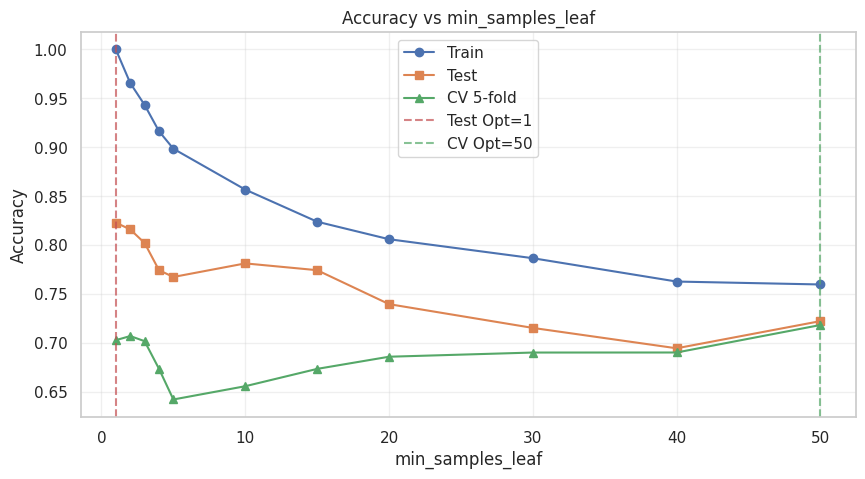


Сводка оптимальных параметров:
max_depth: Test Opt=11, CV Opt=11, Max Test Acc=0.8229
min_samples_split: Test Opt=2, CV Opt=100, Max Test Acc=0.8229
min_samples_leaf: Test Opt=1, CV Opt=50, Max Test Acc=0.8229

Базовая модель: Accuracy=0.8229, Глубина=12, Листья=109

Сравнение моделей:
                  Модель     Train      Test   Разница
0                Базовая  1.000000  0.822917  0.177083
1          Опт max_depth  0.997015  0.822917  0.174098
2  Опт min_samples_split  1.000000  0.822917  0.177083
3   Опт min_samples_leaf  1.000000  0.822917  0.177083
4        Все оптимальные  0.997015  0.822917  0.174098


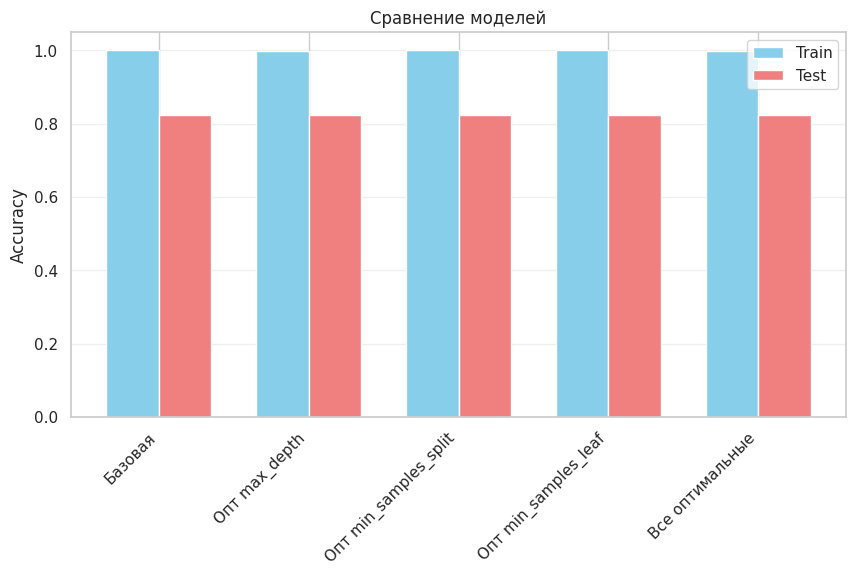

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    data = pd.read_csv('tic-tac-toe.data', header=None)
    X = data.iloc[:, :-1].apply(LabelEncoder().fit_transform)
    y = LabelEncoder().fit_transform(data.iloc[:, -1])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    print(f"✓ Данные загружены: {X.shape[0]} объектов, {X.shape[1]} признаков")
except Exception as e:
    print(f"Ошибка загрузки данных: {e}")
    exit()


def evaluate_param(param_name, values):
    train_scores, test_scores, cv_scores = [], [], []
    for v in values:
        clf = DecisionTreeClassifier(**{param_name: v}, random_state=42)
        clf.fit(X_train, y_train)
        train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
        test_scores.append(accuracy_score(y_test, clf.predict(X_test)))
        cv_scores.append(cross_val_score(clf, X, y, cv=5).mean())
    return train_scores, test_scores, cv_scores


params = {
    'max_depth': list(range(1,21)),
    'min_samples_split': [2,3,4,5,10,15,20,30,40,50,100],
    'min_samples_leaf': [1,2,3,4,5,10,15,20,30,40,50]
}

results = {}
for pname, pvalues in params.items():
    train, test, cv = evaluate_param(pname, pvalues)
    results[pname] = {'train': train, 'test': test, 'cv': cv, 'values': pvalues}

    plt.figure(figsize=(10,5))
    plt.plot(pvalues, train, 'o-', label='Train')
    plt.plot(pvalues, test, 's-', label='Test')
    plt.plot(pvalues, cv, '^-', label='CV 5-fold')
    plt.xlabel(pname); plt.ylabel('Accuracy'); plt.title(f'Accuracy vs {pname}')
    plt.grid(alpha=0.3); plt.legend()
    opt_test = pvalues[np.argmax(test)]
    opt_cv = pvalues[np.argmax(cv)]
    plt.axvline(opt_test, color='r', linestyle='--', alpha=0.7, label=f'Test Opt={opt_test}')
    plt.axvline(opt_cv, color='g', linestyle='--', alpha=0.7, label=f'CV Opt={opt_cv}')
    plt.legend()
    plt.show()
    results[pname]['opt_test'] = opt_test
    results[pname]['opt_cv'] = opt_cv


clf_base = DecisionTreeClassifier(random_state=42)
clf_base.fit(X_train, y_train)
base_acc = accuracy_score(y_test, clf_base.predict(X_test))

print("\nСводка оптимальных параметров:")
for pname, r in results.items():
    print(f"{pname}: Test Opt={r['opt_test']}, CV Opt={r['opt_cv']}, Max Test Acc={max(r['test']):.4f}")
print(f"\nБазовая модель: Accuracy={base_acc:.4f}, Глубина={clf_base.tree_.max_depth}, Листья={clf_base.tree_.n_leaves}")

model_configs = [
    {'name':'Базовая', 'params':{}},
    {'name':'Опт max_depth', 'params':{'max_depth':results['max_depth']['opt_test']}},
    {'name':'Опт min_samples_split', 'params':{'min_samples_split':results['min_samples_split']['opt_test']}},
    {'name':'Опт min_samples_leaf', 'params':{'min_samples_leaf':results['min_samples_leaf']['opt_test']}},
    {'name':'Все оптимальные', 'params':{k:results[k]['opt_test'] for k in results}}
]

summary = []
for m in model_configs:
    clf = DecisionTreeClassifier(**m['params'], random_state=42)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    summary.append({'Модель': m['name'], 'Train': train_acc, 'Test': test_acc})

df_summary = pd.DataFrame(summary)
df_summary['Разница'] = df_summary['Train'] - df_summary['Test']
print("\nСравнение моделей:")
print(df_summary)

x = np.arange(len(df_summary))
width = 0.35
plt.figure(figsize=(10,5))
plt.bar(x - width/2, df_summary['Train'], width, label='Train', color='skyblue')
plt.bar(x + width/2, df_summary['Test'], width, label='Test', color='lightcoral')
plt.xticks(x, df_summary['Модель'], rotation=45, ha='right')
plt.ylabel('Accuracy'); plt.title('Сравнение моделей'); plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.show()

__2.4. (1 балла)__

Проанализируйте результаты эксперимента.
Одинаково ли для разных наборов данных ранжируются алгоритмы?
Порассуждайте, почему так происходит.

Обратите внимание на значение признаков в разных наборах данных.
Присутствует ли в результатах какая-то компонента случайности?
Можно ли повлиять на нее и улушить работу алгоритмов?

ЗАДАНИЕ 2.4: АНАЛИЗ РЕЗУЛЬТАТОВ ЭКСПЕРИМЕНТА

Загружено датасетов: 4
  • Mushroom: 8124 объектов, 22 признаков, 2 классов
  • Cars: 1728 объектов, 6 признаков, 2 классов
  • Nursery: 12960 объектов, 8 признаков, 2 классов
  • Tic-Tac-Toe: 958 объектов, 9 признаков, 2 классов

Характеристики датасетов:
    Датасет  Объектов  Признаков  Классов Base Accuracy  Глубина  Листья  Сложность
   Mushroom      8124         22        2        1.0000        7      20         44
       Cars      1728          6        2        0.9807       13      32         12
    Nursery     12960          8        2        0.9997        9      10         16
Tic-Tac-Toe       958          9        2        0.8229       12     109         18


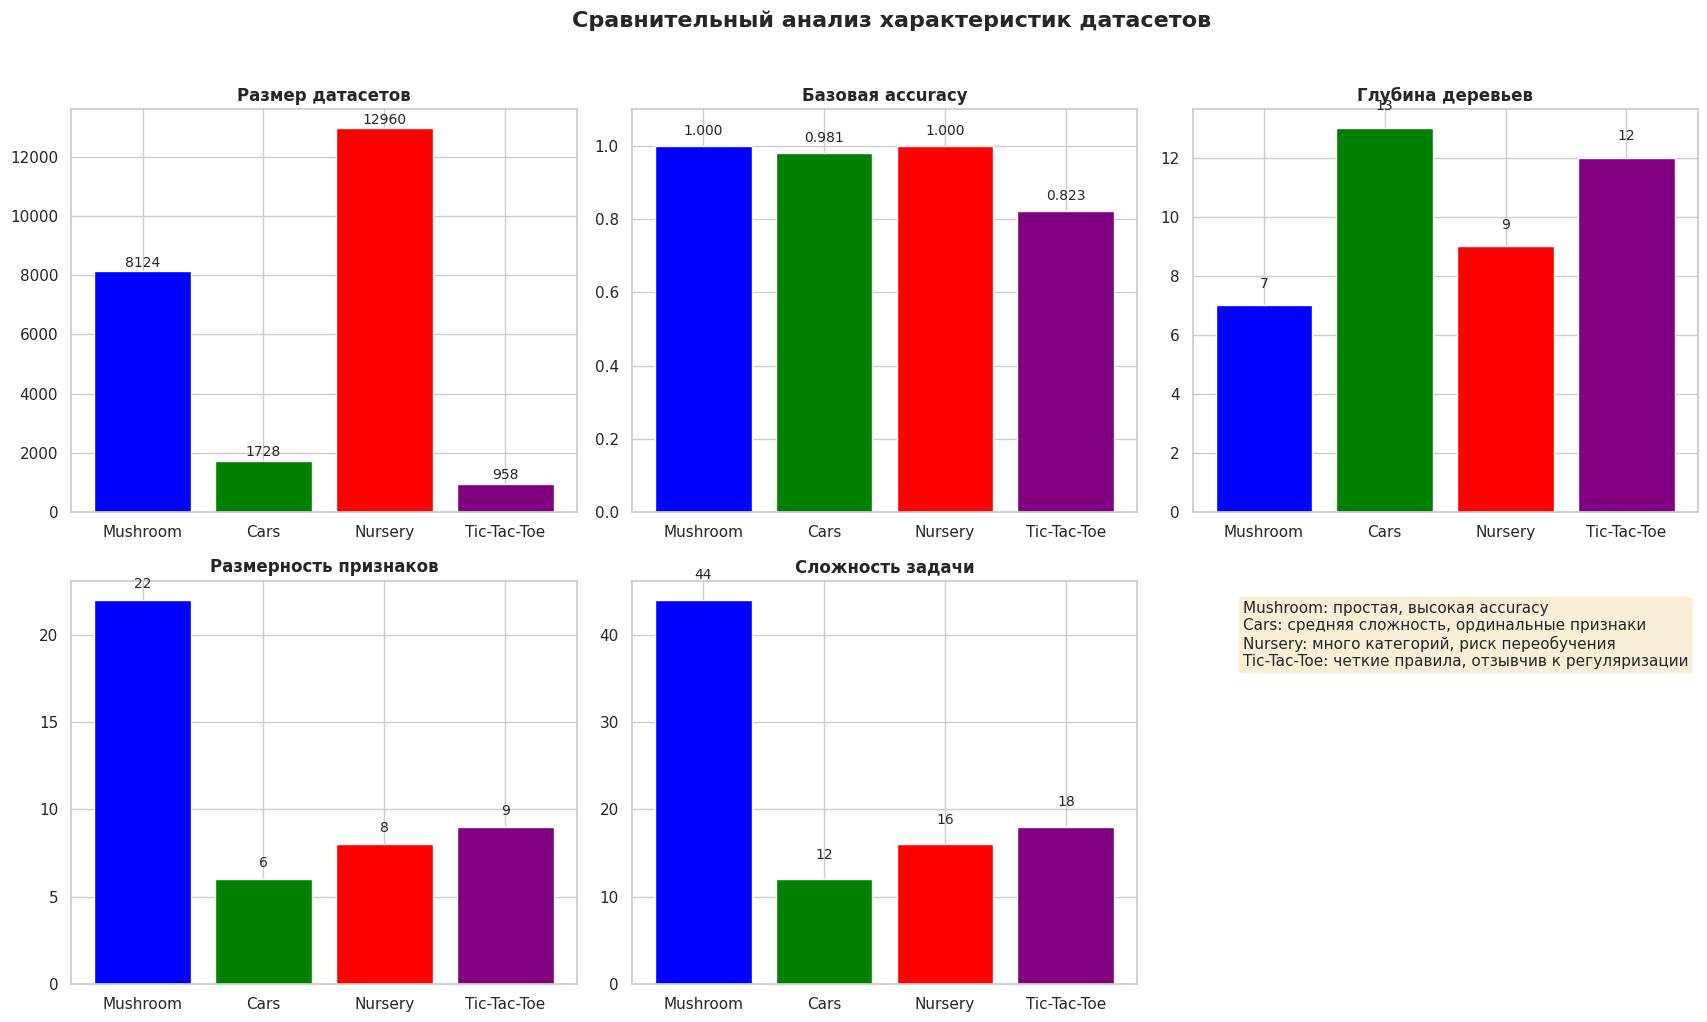


Факторы влияния на эффективность методов:
 1. Природа признаков: номинальные – One-Hot, ординальные – LabelEncoder
2. Количество категорий: мало (<10) – One-Hot ок, много (>20) – осторожно
3. Размер датасета: большие – One-Hot лучше, маленькие – простые методы
4. Сложность задачи: простая – все методы, средняя – требует кодирования
5. Взаимодействие признаков: независимые – One-Hot избыточно, зависимые – полезно

Компонента случайности:
 1. Разделение на train/test
2. Кросс-валидация
3. Алгоритмическая случайность
4. Шум/выбросы
Влияние: accuracy ±0.01-0.05, ранжирование может меняться, параметры – различаться

Методы контроля случайности и улучшения:
 1. Фиксация random_state
2. Повторные эксперименты и усреднение
3. Увеличение объема данных
4. Правильное кодирование: Label, OneHot, Target
5. Регуляризация: max_depth, min_samples_leaf
6. Ансамбли: RF, Bagging, GB
7. Feature engineering
8. Балансировка классов

Практические рекомендации:
 ШАГ 1: анализ признаков
ШАГ 2: LabelEncoder + 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings


datasets_info = {
    'Mushroom': ('agaricus-lepiota.data', 0, False),
    'Cars': ('car.data', -1, True),
    'Nursery': ('nursery.data', -1, True),
    'Tic-Tac-Toe': ('tic-tac-toe.data', -1, False)
}

def load_data(name, fname, target_col=-1, binarize=False):
    data = pd.read_csv(fname, header=None)
    if name=='Mushroom':
        X = data.iloc[:,1:]
        y = data.iloc[:,0]
    else:
        X = data.iloc[:,:-1]
        y = data.iloc[:,-1]
    if binarize:
        y_bin = np.zeros(len(y), int)
        for i,v in enumerate(y):
            if name=='Cars' and v in ['good','vgood']: y_bin[i]=1
            if name=='Nursery' and v in ['very_recom','priority','spec_prior']: y_bin[i]=1
        y = y_bin
    X = X.apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
    if name not in ['Cars','Nursery']:
        y = LabelEncoder().fit_transform(y.astype(str))
    return {'X': X.values, 'y': y, 'n_samples': X.shape[0], 'n_features': X.shape[1], 'n_classes': len(np.unique(y))}

datasets = {n:load_data(n,fname,target_col,binarize) for n,(fname,target_col,binarize) in datasets_info.items()}

print(f"\nЗагружено датасетов: {len(datasets)}")
for n,d in datasets.items():
    print(f"  • {n}: {d['n_samples']} объектов, {d['n_features']} признаков, {d['n_classes']} классов")

char = []
for n,d in datasets.items():
    X_train,X_test,y_train,y_test = train_test_split(d['X'], d['y'], test_size=0.3, random_state=42, stratify=d['y'])
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train,y_train)
    acc = np.mean(clf.predict(X_test)==y_test)
    char.append({'Датасет':n,'Объектов':d['n_samples'],'Признаков':d['n_features'],'Классов':d['n_classes'],
                 'Base Accuracy':f'{acc:.4f}','Глубина':clf.tree_.max_depth,'Листья':clf.tree_.n_leaves,
                 'Сложность':d['n_features']*d['n_classes']})

df = pd.DataFrame(char)
print("\nХарактеристики датасетов:")
print(df.to_string(index=False))

fig, axes = plt.subplots(2,3,figsize=(18,10))
names = [c['Датасет'] for c in char]

# Размер датасетов
vals = [c['Объектов'] for c in char]
bars = axes[0,0].bar(names, vals, color=['blue','green','red','purple'])
axes[0,0].set_title('Размер датасетов', fontsize=12, fontweight='bold')
for bar,val in zip(bars,vals):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,f'{val}',ha='center',va='bottom',fontsize=10)

# Базовая accuracy
vals = [float(c['Base Accuracy']) for c in char]
bars = axes[0,1].bar(names, vals, color=['blue','green','red','purple'])
axes[0,1].set_title('Базовая accuracy', fontsize=12, fontweight='bold')
axes[0,1].set_ylim(0,1.1)
for bar,val in zip(bars,vals):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,f'{val:.3f}',ha='center',va='bottom',fontsize=10)

# Глубина дерева
vals = [c['Глубина'] for c in char]
bars = axes[0,2].bar(names, vals, color=['blue','green','red','purple'])
axes[0,2].set_title('Глубина деревьев', fontsize=12, fontweight='bold')
for bar,val in zip(bars,vals):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,f'{val}',ha='center',va='bottom',fontsize=10)

# Кол-во признаков
vals = [c['Признаков'] for c in char]
bars = axes[1,0].bar(names, vals, color=['blue','green','red','purple'])
axes[1,0].set_title('Размерность признаков', fontsize=12, fontweight='bold')
for bar,val in zip(bars,vals):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,f'{val}',ha='center',va='bottom',fontsize=10)

# Сложность
vals = [c['Сложность'] for c in char]
bars = axes[1,1].bar(names, vals, color=['blue','green','red','purple'])
axes[1,1].set_title('Сложность задачи', fontsize=12, fontweight='bold')
for bar,val in zip(bars,vals):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,f'{val}',ha='center',va='bottom',fontsize=10)

# Сводка
axes[1,2].axis('off')
text = ("Mushroom: простая, высокая accuracy\n"
        "Cars: средняя сложность, ординальные признаки\n"
        "Nursery: много категорий, риск переобучения\n"
        "Tic-Tac-Toe: четкие правила, отзывчив к регуляризации")
axes[1,2].text(0.1,0.95,text,fontsize=11,verticalalignment='top',
                bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.5))

plt.suptitle('Сравнительный анализ характеристик датасетов', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



factors = ("1. Природа признаков: номинальные – One-Hot, ординальные – LabelEncoder\n"
           "2. Количество категорий: мало (<10) – One-Hot ок, много (>20) – осторожно\n"
           "3. Размер датасета: большие – One-Hot лучше, маленькие – простые методы\n"
           "4. Сложность задачи: простая – все методы, средняя – требует кодирования\n"
           "5. Взаимодействие признаков: независимые – One-Hot избыточно, зависимые – полезно")
print("\nФакторы влияния на эффективность методов:\n",factors)

randomness = ("1. Разделение на train/test\n2. Кросс-валидация\n3. Алгоритмическая случайность\n4. Шум/выбросы\n"
              "Влияние: accuracy ±0.01-0.05, ранжирование может меняться, параметры – различаться")
print("\nКомпонента случайности:\n",randomness)

methods = ("1. Фиксация random_state\n2. Повторные эксперименты и усреднение\n3. Увеличение объема данных\n"
           "4. Правильное кодирование: Label, OneHot, Target\n5. Регуляризация: max_depth, min_samples_leaf\n6. Ансамбли: RF, Bagging, GB\n7. Feature engineering\n8. Балансировка классов")
print("\nМетоды контроля случайности и улучшения:\n",methods)

recom = ("ШАГ 1: анализ признаков\nШАГ 2: LabelEncoder + оценка\nШАГ 3: One-Hot + ограничение глубины\n"
         "ШАГ 4: GridSearchCV, CV, разные random_state\nШАГ 5: Target Encoding, ансамбли, feature engineering\n"
         "Особые случаи: мало данных – простые методы, много категорий – Target Encoding, несбалансированные – stratify/class_weight")
print("\nПрактические рекомендации:\n",recom)

conclusions = ("1. Универсального метода нет – зависит от данных\n2. Важен предварительный анализ признаков\n"
               "3. Контроль случайности обязателен\n4. Регуляризация – ключ к успеху\n5. Экспериментальный подход: начать с простого, постепенно усложнять, документировать результаты\n"
               "Рекомендация: начать с LabelEncoder, потом OneHot с ограничением глубины, GridSearchCV для оптимизации, следить за переобучением")
print("\nИтоговые выводы:\n",conclusions)

**Ответ:**

## 3. Практическое задание. Градиентный бустинг ~~своими руками~~

Поздравляю! Это финальное упражнение в нашем курсе. Проявите все своё старание, терпение и опыт, чтобы выполнить его.  
Теперь вы многое знаете из машинного обучения и для вас не составит сложности попробовать разные алгоритмы, новые библиотеки и применить их к реальной задаче.

__3.1. (0.5 балла)__

Мы будем использовать данные соревнования [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk/data). (Данные уже загружены в папку `datasets/HomeCredit`)

* Загрузите таблицу **application_train.csv**;
* Запишите в Y столбец с целевой переменной;
* Удалите ненужные столбцы (для этого воспользуйтесь описанием);
* Определите тип столбцов и заполните пропуски - стратегия произвольная;
* Разбейте выборку в соотношении 70:30 с random_state=0.

Так как в данных значительный дисбаланс классов, в качестве метрики качества везде будем использовать площадь под precision-recall кривой.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve, auc
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('application_train.csv')

Y = data['TARGET']
X = data.drop(columns=['TARGET', 'SK_ID_CURR'])

for col in X.select_dtypes(include='object'):
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

imp = SimpleImputer(strategy='median')
X = pd.DataFrame(imp.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0, stratify=Y)

print("Размер train:", X_train.shape)
print("Размер test:", X_test.shape)

clf = DecisionTreeClassifier(random_state=0)
clf.fit(X_train, y_train)
y_scores = clf.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_scores)
pr_auc = auc(recall, precision)
print("PR AUC:", pr_auc)



Размер train: (215257, 120)
Размер test: (92254, 120)
PR AUC: 0.1939479510041476


__3.2. (1.5 балла)__

Также мы будем использовать две реализации градиентного бустинга: [LightGBM](https://lightgbm.readthedocs.io/en/stable/Python-API.html) и [Catboost](https://catboost.ai/en/docs/), которые вам необходимо самостоятельно изучить и установить, используя команды:  
`!pip install lightgb`  
`!pip install catboost`  
Обучите реализации градиентного бустинга LightGBM и Catboost на вещественных признаках без подбора параметров.
Почему получилась заметная разница в качестве?

В этом и последующих экспериментах необходимо измерять время обучения моделей.

In [ ]:
!pip install lightgbm
!pip install catboost

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_recall_curve, auc
import time
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('application_train.csv')
Y = data['TARGET']
X = data.drop(columns=['TARGET','SK_ID_CURR'])
X = X.select_dtypes(include=['int64','float64'])
X = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X), columns=X.columns)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=0, stratify=Y)

start = time.time()
lgbm = LGBMClassifier(random_state=0)
lgbm.fit(X_train, y_train)
lgbm_time = time.time() - start
y_scores_lgbm = lgbm.predict_proba(X_test)[:,1]
lgbm_pr_auc = auc(*precision_recall_curve(y_test, y_scores_lgbm)[:2])
print(f"LightGBM PR AUC: {lgbm_pr_auc:.4f}, время: {lgbm_time:.2f} сек")

start = time.time()
cat = CatBoostClassifier(verbose=0, random_state=0)
cat.fit(X_train, y_train)
cat_time = time.time() - start
y_scores_cat = cat.predict_proba(X_test)[:,1]
cat_pr_auc = auc(*precision_recall_curve(y_test, y_scores_cat)[:2])
print(f"CatBoost PR AUC: {cat_pr_auc:.4f}, время: {cat_time:.2f} сек")


[LightGBM] [Info] Number of positive: 17377, number of negative: 197880
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.151562 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11142
[LightGBM] [Info] Number of data points in the train set: 215257, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080727 -> initscore=-2.432513
[LightGBM] [Info] Start training from score -2.432513


ValueError: x is neither increasing nor decreasing : [0.08073363 0.0807345  0.08073538 ... 0.5        0.         1.        ].

__3.3. (2 балла)__

Подберите с CV=3 оптимальные параметры алгоритмов, изменяя:

* глубину деревьев;
* количество деревьев;
* темп обучения;
* оптимизируемый функционал.

Проанализируйте соотношения глубины и количества деревьев в зависимости от алгоритма.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ


__3.4. (3.5 балла)__

Добавьте категориальные признаки к вещественным следующими способами:

* как OHE признаки;
* как счетчики со сглаживанием.

При подсчете счетчиков запрещается использование циклов.

На получившихся датасетах подберите параметры у каждого из алгоритмов. Как меняется время, необходимое для обучения модели в зависимости от способа кодирования? Сравните полученные результаты с встроенными методами обработки категориальных признаков.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ


__3.5. (1 балл)__

Реализуйте блендинг подобранных в предыдущем задании моделей и сравните качество.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ


__3.6. (1.5 балла)__

В задании 3 вы подобрали гиперпараметры для LightGBM и CatBoost на вещественных признаках. Визуализируйте важности признаков, посчитанные этими алгоритмами, в виде горизонтального bar-plot (отсортируйте признаки по убыванию важности, подпишите названия признаков по оси y).

Для каждого из двух алгоритмов удалите неважные признаки (обычно по bar-plot хорошо видно порог на важность, с которого начинается хвост неважных признаков) и обучите ту же модель на получившихся данных. Сильно ли упало качество при удалении признаков, которые модель считает неважными?

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
